### Apartado 5 (Regresión)

En este apartado realizamos un problema de regresión utilizando el dataset music_regression.csv.  

Se comparan dos modelos:

- **Regresión Lineal** 
- **Árbol de Regresión (DecisionTreeRegressor)** 

Los hiperparámetros del árbol se han tomado de los óptimos encontrados en el Apartado 3.

Las métricas evaluadas son:

- MAE (Mean Absolute Error)
- MSE (Mean Squared Error)
- RMSE (Root Mean Squared Error)
- R² (Coeficiente de Determinación)

Al igual que en el apartado 4 se evalúan tres esquemas:
1. Hold-out simple (75/25)  
2. 10 Hold-outs repetidos  
3. Validación cruzada 5-fold


# Cargamos los datos 

In [1]:
import pandas as pd
import numpy as np

df_reg = pd.read_csv("music_regression.csv")
display(df_reg.head())

target = "Popularity"

X_reg = df_reg.drop(columns=[target]).values
y_reg = df_reg[target].values

,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,liveness,valence,tempo,duration_in min/ms,time_signature
0,60.0,0.854,0.564,1.0,-4.964,1,0.0485,0.017100,0.0849,0.8990,134.071,234596.0,4
1,54.0,0.382,0.814,3.0,-7.230,1,0.0406,0.001100,0.1010,0.5690,116.454,251733.0,4
2,35.0,0.434,0.614,6.0,-8.334,1,0.0525,0.486000,0.3940,0.7870,147.681,109667.0,4
3,66.0,0.853,0.597,10.0,-6.528,0,0.0555,0.021200,0.1220,0.5690,107.033,173968.0,4
4,53.0,0.167,0.975,2.0,-4.279,1,0.2160,0.000169,0.1720,0.0918,199.060,229960.0,4


# Métricas que vamos a usar

In [2]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def compute_reg_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }


# Definimos los modelos

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

def make_linreg():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("reg", LinearRegression())
    ])

def make_tree_reg():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("reg", DecisionTreeRegressor(min_samples_leaf=20, ccp_alpha=0.0, random_state=0))
    ])


Imputamos en ambos y solo estndarizamos en el de regresión lineal.

# A: Hold out único 75-25

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=0
)

# Lineal
lin = make_linreg().fit(X_train, y_train)
pred_lin = lin.predict(X_test)
metrics_lin_ho = compute_reg_metrics(y_test, pred_lin)

# Árbol
tree = make_tree_reg().fit(X_train, y_train)
pred_tree = tree.predict(X_test)
metrics_tree_ho = compute_reg_metrics(y_test, pred_tree)

display(pd.DataFrame([metrics_lin_ho], index=["LinearRegression"]))
display(pd.DataFrame([metrics_tree_ho], index=["DecisionTreeRegressor"]))

,MAE,MSE,RMSE,R2
LinearRegression,13.624835,288.4922,16.985058,0.059124


,MAE,MSE,RMSE,R2
DecisionTreeRegressor,13.999944,317.041859,17.805669,-0.033987


# Comparación gráfica

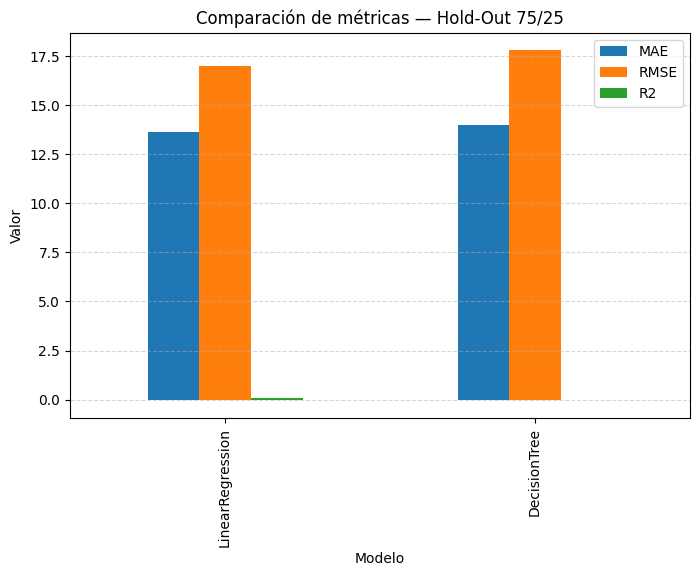

In [6]:
import matplotlib.pyplot as plt

metrics_ho = pd.DataFrame({
    "LinearRegression": metrics_lin_ho,
    "DecisionTree": metrics_tree_ho
}).T[["MAE", "RMSE", "R2"]]

metrics_ho.plot(kind="bar", figsize=(8,5))
plt.title("Comparación de métricas — Hold-Out 75/25")
plt.xlabel("Modelo")
plt.ylabel("Valor")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


#### Interpretación de resultados 
En esta partición única del conjunto de datos, la regresión lineal obtiene menores valores de MAE y RMSE que el árbol de decisión, lo que indica un error promedio más bajo y, en general, mejores predicciones. Además, la regresión lineal presenta un R_2 ligeramente positivo, lo que significa que explica una pequeña parte de la variabilidad de la popularidad, aunque de forma limitada.

Por el contrario, el árbol de decisión obtiene un R_2 negativo, lo que implica que su desempeño es peor que un modelo trivial que predice siempre el valor medio. Esto sugiere falta de capacidad de generalización en esta partición concreta, probablemente debido a sobreajuste y a que la relación entre variables parece más adecuada para modelos lineales que para particiones jerárquicas como las de un árbol.

En resumen, bajo un único hold-out, la regresión lineal ofrece un rendimiento superior y más estable que el árbol de decisión.

# B: 10 Hold-Outs Repetidos

In [7]:
def repeated_holdout_reg(make_model, X, y, repeats=10):
    results = []
    for seed in range(repeats):
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=0.25, random_state=seed
        )
        model = make_model().fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        results.append(compute_reg_metrics(y_te, y_pred))

    return pd.DataFrame(results).agg(["mean", "std"]).T


print("\nRegresión Lineal:")
display(repeated_holdout_reg(make_linreg, X_reg, y_reg))

print("\nÁrbol de decisión:")
display(repeated_holdout_reg(make_tree_reg, X_reg, y_reg))



Regresión Lineal:


,mean,std
MAE,13.563584,0.086653
MSE,287.046048,2.524662
RMSE,16.942286,0.074604
R2,0.056447,0.005116



Árbol de decisión:


,mean,std
MAE,13.916734,0.178940
MSE,309.823605,7.191926
RMSE,17.600727,0.205526
R2,-0.018397,0.021199


# Comparación gráfica

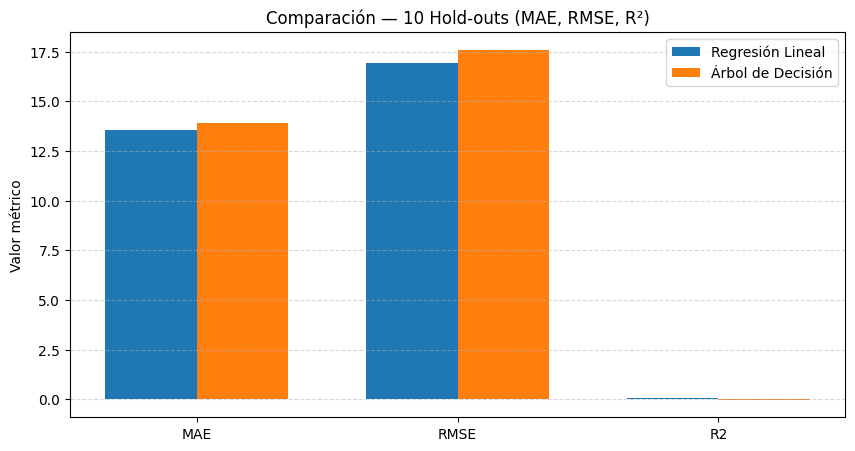

In [13]:
df_lin_10 = repeated_holdout_reg(make_linreg, X_reg, y_reg)
df_tree_10 = repeated_holdout_reg(make_tree_reg, X_reg, y_reg)

metrics = ["MAE", "RMSE", "R2"]

lin_vals_10 = df_lin_10["mean"].loc[metrics].values
tree_vals_10 = df_tree_10["mean"].loc[metrics].values

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10,5))
plt.bar(x - width/2, lin_vals_10, width, label="Regresión Lineal")
plt.bar(x + width/2, tree_vals_10, width, label="Árbol de Decisión")

plt.xticks(x, metrics)
plt.ylabel("Valor métrico")
plt.title("Comparación — 10 Hold-outs (MAE, RMSE, R²)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.show()


#### Interpretación
Los resultados muestran que la Regresión Lineal obtiene un rendimiento ligeramente superior al Árbol de Decisión. Presenta menor MAE, menor MSE/RMSE y un valor positivo de R_2, lo que indica cierta capacidad explicativa del modelo. En contraste, el modelo basado en árboles presenta peor ajuste, mayor error y un R_2 negativo, lo que sugiere que no mejora la predicción frente a usar simplemente la media del conjunto de entrenamiento. Además, la desviación estándar es más baja en la regresión lineal, reflejando un comportamiento más estable entre particiones, mientras que el árbol presenta mayor variabilidad.

# C: Validación Cruzada 5-Fold

In [10]:
from sklearn.model_selection import KFold, cross_val_predict

kf = KFold(n_splits=5, shuffle=True, random_state=0)

# Lineal
y_pred_lin_cv = cross_val_predict(make_linreg(), X_reg, y_reg, cv=kf)
metrics_lin_cv = compute_reg_metrics(y_reg, y_pred_lin_cv)

# Árbol
y_pred_tree_cv = cross_val_predict(make_tree_reg(), X_reg, y_reg, cv=kf)
metrics_tree_cv = compute_reg_metrics(y_reg, y_pred_tree_cv)

display(pd.DataFrame([metrics_lin_cv], index=["LinearRegression"]))
display(pd.DataFrame([metrics_tree_cv], index=["DecisionTreeRegressor"]))


,MAE,MSE,RMSE,R2
LinearRegression,13.508404,285.25923,16.889619,0.06066


,MAE,MSE,RMSE,R2
DecisionTreeRegressor,13.892879,308.232366,17.556548,-0.014989


# Comparación gráfica

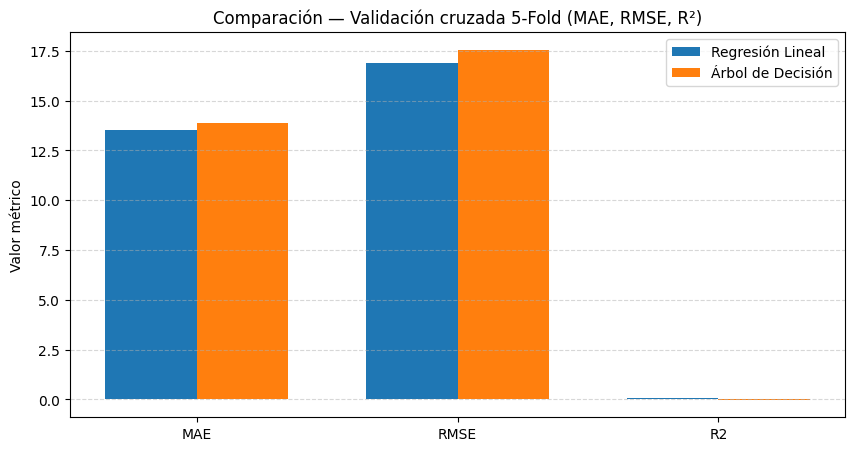

In [11]:
df_cv = pd.DataFrame({
    "LinearRegression": metrics_lin_cv,
    "DecisionTreeRegressor": metrics_tree_cv
}).T

import matplotlib.pyplot as plt
import numpy as np

metrics = ["MAE", "RMSE", "R2"]

lin_vals_cv = df_cv.loc["LinearRegression", metrics].values
tree_vals_cv = df_cv.loc["DecisionTreeRegressor", metrics].values

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10,5))
plt.bar(x - width/2, lin_vals_cv, width, label="Regresión Lineal")
plt.bar(x + width/2, tree_vals_cv, width, label="Árbol de Decisión")

plt.xticks(x, metrics)
plt.ylabel("Valor métrico")
plt.title("Comparación — Validación cruzada 5-Fold (MAE, RMSE, R²)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.show()

#### Interpretación
Los resultados muestran que la regresión lineal obtiene menor MSE y RMSE y un R_2 positivo , lo que indica una capacidad de predicción moderadamente mejor y cierta habilidad de generalización.

En contraste, el árbol de decisión presenta mayor error (MSE y RMSE superiores) y un R_2 negativo, lo que sugiere que no logra capturar adecuadamente la estructura del problema y rinde peor que un modelo base que predijera la media constante.

En conjunto, la regresión lineal es más robusta y generaliza mejor bajo validación cruzada, mientras que el árbol tiende a sobreajustarse y ofrecer peor rendimiento promedio.

#### Conclusiones generales 
En todos los métodos de validación, la regresión lineal supera al árbol de decisión, mostrando menor MAE/RMSE y valores de R_2 positivos, mientras que el árbol presenta errores mayores y R_2 cercano o negativo, indicando peor capacidad de generalización.

El hold-out simple es el método menos estable, ya que depende fuertemente de una única partición. Los 10 hold-outs repetidos y la validación cruzada 5-fold ofrecen resultados más consistentes, siendo la validación cruzada la opción más equilibrada en coste computacional y fiabilidad.

En conjunto, la regresión lineal es el modelo recomendado para este problema, especialmente evaluado mediante validación cruzada.

#### Comparaciones con la práctica anterior 
Al comparar los modelos empleados en esta práctica (Regresión Lineal y DecisionTreeRegressor) con los utilizados en la práctica anterior (variantes de KNN, OneR y ZeroR), se observan varios patrones consistentes en cuanto a rendimiento y capacidad de generalización. En términos globales, la Regresión Lineal presenta un desempeño superior frente al Árbol de Decisión, con menores valores de MAE y RMSE y valores de R² positivos, mientras que el árbol tiende a sobreajustar, obteniendo valores de R_2 cercanos a cero o negativos y una mayor variabilidad entre particiones. Este comportamiento es coherente con la práctica anterior, donde los modelos que imponen una estructura global (como myKNN con k alto y KNN con k moderado) presentaban mejor rendimiento que aquellos más sensibles al ruido y la fragmentación del espacio, como KNN con k pequeño o ZeroR.

En cuanto a los esquemas de validación, tanto en esta práctica como en la anterior, la validación 5-Fold proporciona estimaciones más estables y ligeramente más optimistas, mientras que el hold-out único muestra una mayor sensibilidad a la partición concreta de los datos. Los 10 hold-outs repetidos ofrecen un compromiso adecuado, reflejando con mayor fiabilidad la variabilidad esperada sin el coste computacional de creciente la validación cruzada. De manera consistente, los modelos más robustos (Regresión Lineal, myKNN con k grandes) muestran menor desviación estándar entre particiones, mientras que los modelos más inestables (Árbol de Decisión, KNN con k pequeño) reflejan diferencias más marcadas entre esquemas de validación.